In [2]:
import pandas as pd

real = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\data\final_data_cleaned_with_author_names.csv")
llama_few_shot = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v9_3.2_3B_objective_with_length_dist\generated_comments_v9.csv")
llama_finetuned = pd.read_csv(r"C:\Users\20245179\OneDrive - TU Eindhoven\WP2_Simulation_Tool\Fine_Tune_LLAMA\v10_3.1_8B_objective_with_length_dist\generated_comments_v10.csv")

# Calculate word counts to find the maximum
real_word_counts = real["text"].str.split().str.len()

#Find index of maximum word count
max_word_count_idx = real_word_counts.idxmax()
print(f"Removing row {max_word_count_idx} with {real_word_counts.max()} words")
print(f"Text being removed: {real.iloc[max_word_count_idx]['text'][:100]}...")

# Remove the row with maximum word count
real = real.drop(max_word_count_idx).reset_index(drop=True)

Removing row 1500 with 1124 words
Text being removed: Vanaf juni 2011 verhuurt <ORG> deze woningen via Woonvast Makelaars te Amersfoort Vanaf de eerste da...


In [3]:
real

,parent_id,id,author_id,time,title,text,post_url,reactions,year,nu_words,ha_id,text_ha,author_name
0,ZmVlZGJhY2s6MjA0MDM2MDg0NjAxMzE1NA==,ZmVlZGJhY2s6MjA0MDM2MDg0NjAxMzE1NF8yMDQxMDI4Nj...,100001659249038,2019-04-02T22:14:59,NaN,hoeveel KWh hebben de zonnepanelen op de wezen...,0,0,2019,10,100034431854919,De zonnepanelen op het dak van ons kantoor doe...,WormerWonen
1,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzMw==,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzM18yMDc5MTcxNj...,1204819098,2018-12-21T15:37:26,NaN,Dan kom ik langs voor sleutels en krijg er gra...,0,0,2018,17,100031130900343,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Actium
2,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzMw==,ZmVlZGJhY2s6MjA0ODM5MDA5ODU1MTgzM18yMDc4ODYzNj...,627271250,2018-12-21T10:57:48,NaN,"Mmmm, iets nieuws? Wij hebben in maart geen wi...",0,0,2018,10,100031130900343,IN ACTI-UM | Onze vakmannen vervangen bij iede...,Actium
3,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNA==,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNF8yMDc1OTI1Mj...,100001478616616,2018-08-01T15:22:31,NaN,Het zou beter zijn als Samenwerking een aantal...,0,0,2018,23,100067754302074,Een hoog energieverbruik is slecht voor het mi...,NaN
4,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNA==,ZmVlZGJhY2s6MjA1MDEwNjkzMTY4ODQzNF8yMDczOTE5Nj...,100000855817347,2018-07-31T11:51:36,NaN,Leuk als je in een woning woont met warmtepomp...,0,0,2018,34,100067754302074,Een hoog energieverbruik is slecht voor het mi...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3191,ZmVlZGJhY2s6OTU1MjE0NDg0ODMyNDYw,ZmVlZGJhY2s6OTU1MjE0NDg0ODMyNDYwXzk1NTIyMDUzND...,100001182464975,2019-07-30T10:57:55,NaN,Kijk onze wijk <PERSON> <PERSON> Paulo Mariaa ...,0,2,2019,20,100063528101921,Vorige week zijn de laatste huizen van 't Getf...,De Woonplaats
3192,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIx,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIxXzk2NjA4NTQ4Nz...,596212634,2020-10-22T12:40:07,NaN,Is er genoeg ventilatie en / of kunnen ramen g...,0,0,2020,10,100063452708421,Op de 1e verdieping van het oude schoolgebouw ...,Woongoed Zeist
3193,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIx,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIxXzk2NTQwMTMyNz...,100001224379149,2020-10-21T15:54:40,NaN,<PERSON> kan je dus straks gebruik van maken. ...,0,0,2020,21,100063452708421,Op de 1e verdieping van het oude schoolgebouw ...,Woongoed Zeist
3194,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIx,ZmVlZGJhY2s6OTYwNDYyMjc0MzY0NTIxXzk2MzU0MDgwNz...,100002916564091,2020-10-19T10:14:18,NaN,Komen er nog meer werkplekken bij? Of blijft h...,0,0,2020,16,100063452708421,Op de 1e verdieping van het oude schoolgebouw ...,Woongoed Zeist


In [4]:
real_word_count = real["text"].str.split().str.len()
llama_few_shot_word_count = llama_few_shot["generated_comment"].str.split().str.len()
llama_finetuned_word_count = llama_finetuned["generated_comment"].str.split().str.len()

print("Word Count Statistics (after removing maximum word count sentence):")
print("=" * 60)
print(f"Real comments - Count: {len(real_word_count)}, Mean words: {real_word_count.mean():.2f}, Median: {real_word_count.median():.2f}, Min: {real_word_count.min()}, Max: {real_word_count.max()}")
print(f"Llama few-shot generated - Count: {len(llama_few_shot_word_count)}, Mean words: {llama_few_shot_word_count.mean():.2f}, Median: {llama_few_shot_word_count.median():.2f}, Min: {llama_few_shot_word_count.min()}, Max: {llama_few_shot_word_count.max()}")
print(f"Llama finetuned generated - Count: {len(llama_finetuned_word_count)}, Mean words: {llama_finetuned_word_count.mean():.2f}, Median: {llama_finetuned_word_count.median():.2f}, Min: {llama_finetuned_word_count.min()}, Max: {llama_finetuned_word_count.max()}")

Word Count Statistics (after removing maximum word count sentence):
Real comments - Count: 3196, Mean words: 20.51, Median: 12.00, Min: 1, Max: 336
Llama few-shot generated - Count: 3197, Mean words: 24.62, Median: 19.00, Min: 2, Max: 120
Llama finetuned generated - Count: 3197, Mean words: 26.11, Median: 21.00, Min: 2, Max: 109


In [5]:
import numpy as np
from dataclasses import dataclass
from typing import List, Dict, Optional

@dataclass(frozen=True)
class WordLenBin:
    lo: int      # inclusive
    hi: int      # inclusive
    p: float     # probability mass

def word_lengths(texts: List[str]) -> np.ndarray:
    return np.array([len(str(t).split()) for t in texts], dtype=int)

def make_fixed_width_bins(
    texts: List[str],
    bin_width: int = 5,
    min_len: int = 1,
    max_len: Optional[int] = None,
    add_overflow_bin: bool = True
) -> List[WordLenBin]:
    """
    Equal-width word-count bins: [min_len..min_len+W-1], [min_len+W..min_len+2W-1], ...
    Probabilities are empirical (fraction of real comments in each bin).

    If add_overflow_bin=True and max_len is set, the last bin is [max_len+1 .. observed_max].
    If max_len is None, bins go up to observed_max and overflow bin is not needed.
    """
    x = word_lengths(texts)
    x = x[x >= 0]
    if len(x) == 0:
        raise ValueError("No texts/lengths provided.")
    if bin_width < 1:
        raise ValueError("bin_width must be >= 1")

    observed_max = int(x.max())
    if max_len is None:
        max_len = observed_max

    # Build equal-width edges up to max_len
    # Example: min=1, width=5 -> bins: 1-5, 6-10, 11-15, ...
    edges = list(range(min_len, max_len + bin_width, bin_width))
    # Ensure last edge covers max_len
    if edges[-1] <= max_len:
        edges.append(edges[-1] + bin_width)

    bins: List[WordLenBin] = []
    n = len(x)

    # Fixed-width bins up to max_len
    for start in edges[:-1]:
        lo = start
        hi = start + bin_width - 1
        # Clip the final fixed bin to max_len (optional, keeps geometry consistent except last cap)
        if hi > max_len:
            hi = max_len
        if lo > hi:
            continue

        count = int(((x >= lo) & (x <= hi)).sum())
        p = count / n
        # Keep empty bins if you want a complete grid; otherwise skip.
        bins.append(WordLenBin(lo=lo, hi=hi, p=p))

    # Optional overflow tail bin to catch lengths > max_len
    if add_overflow_bin and observed_max > max_len:
        lo = max_len + 1
        hi = observed_max
        count = int((x >= lo).sum())
        p = count / n
        bins.append(WordLenBin(lo=lo, hi=hi, p=p))

    # Renormalize (in case you clipped / overflow logic)
    total = sum(b.p for b in bins)
    if total == 0:
        raise ValueError("All bins have zero mass; check min_len/max_len/bin_width.")
    bins = [WordLenBin(b.lo, b.hi, b.p / total) for b in bins]

    return bins

def sample_word_bin(bins: List[WordLenBin], seed: Optional[int] = None) -> WordLenBin:
    rng = np.random.default_rng(seed)
    ps = np.array([b.p for b in bins], dtype=float)
    ps = ps / ps.sum()
    idx = rng.choice(len(bins), p=ps)
    return bins[int(idx)]

def bins_as_dict(bins: List[WordLenBin]) -> Dict[str, float]:
    return {f"{b.lo}-{b.hi}": b.p for b in bins}


real_comments = real["text"].tolist()

bins = make_fixed_width_bins(
    texts=real_comments,
    bin_width=5,      # choose 3, 5, 10 depending on granularity you want
    min_len=1,
    max_len=None,      # optional cap; tail goes to overflow bin if add_overflow_bin=True
    add_overflow_bin=True
)

print(bins_as_dict(bins))

for _ in range(10):
    b = sample_word_bin(bins)
    print("Sampled bin:", b)


{'1-5': 0.28035043804755944, '6-10': 0.1830413016270338, '11-15': 0.13016270337922403, '16-20': 0.09292866082603254, '21-25': 0.0678973717146433, '26-30': 0.054130162703379225, '31-35': 0.0353566958698373, '36-40': 0.02690863579474343, '41-45': 0.023153942428035045, '46-50': 0.02002503128911139, '51-55': 0.016270337922403004, '56-60': 0.004380475594493116, '61-65': 0.009073842302878598, '66-70': 0.0050062578222778474, '71-75': 0.008448060075093867, '76-80': 0.00688360450563204, '81-85': 0.004067584480600751, '86-90': 0.004380475594493116, '91-95': 0.00344180225281602, '96-100': 0.00344180225281602, '101-105': 0.0018773466833541927, '106-110': 0.0018773466833541927, '111-115': 0.002190237797246558, '116-120': 0.0006257822277847309, '121-125': 0.0012515644555694619, '126-130': 0.0009386733416770963, '131-135': 0.0015644555694618273, '136-140': 0.00031289111389236547, '141-145': 0.0006257822277847309, '146-150': 0.0006257822277847309, '151-155': 0.0009386733416770963, '156-160': 0.0012515

In [6]:
## Calculate comment lengths for all datasets (after removing max word count sentence)

# Calculate text lengths
real_length = real["text"].str.len()
llama_few_shot_length = llama_few_shot["generated_comment"].str.len()
llama_finetuned_length = llama_finetuned["generated_comment"].str.len()

print(f"Real comments - Count: {len(real_length)}, Mean length: {real_length.mean():.2f}, Median: {real_length.median():.2f}, Minimum: {real_length.min()}, Maximum: {real_length.max()}")
print(f"Llama few-shot generated - Count: {len(llama_few_shot_length)}, Mean length: {llama_few_shot_length.mean():.2f}, Median: {llama_few_shot_length.median():.2f},Minimum: {llama_few_shot_length.min()}, Maximum: {llama_few_shot_length.max()}")
print(f"Llama finetuned generated - Count: {len(llama_finetuned_length)}, Mean length: {llama_finetuned_length.mean():.2f}, Median: {llama_finetuned_length.median():.2f}, Minimum: {llama_finetuned_length.min()}, Maximum: {llama_finetuned_length.max()}")

Real comments - Count: 3196, Mean length: 118.20, Median: 68.00, Minimum: 1, Maximum: 2089
Llama few-shot generated - Count: 3197, Mean length: 139.32, Median: 112.00,Minimum: 30, Maximum: 589
Llama finetuned generated - Count: 3197, Mean length: 148.24, Median: 115.00, Minimum: 28, Maximum: 577


In [7]:
# Check sorted lengths after removing max word count sentence
real_length_sorted = real_length.sort_values(ascending=False)

llama_few_shot_length_sorted = llama_few_shot_length.sort_values(ascending=False)
llama_finetuned_length_sorted = llama_finetuned_length.sort_values(ascending=False)

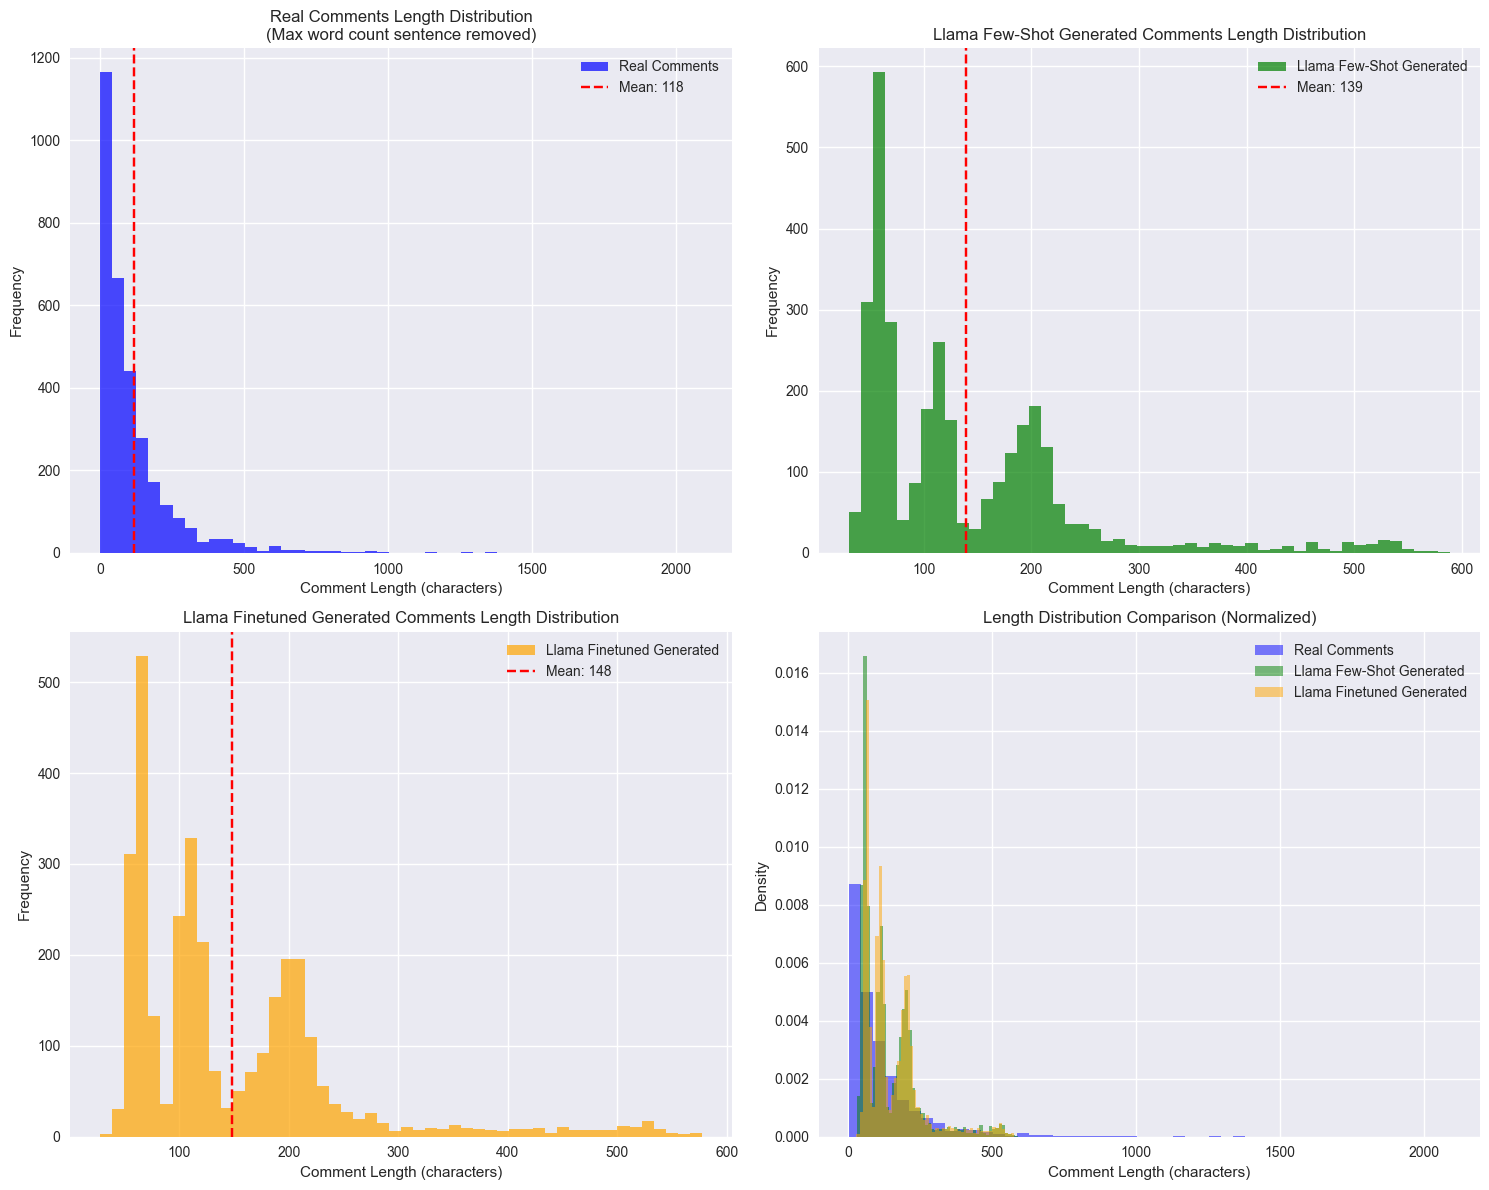

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set style for better looking plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Individual histograms for each dataset (real data already has max word count sentence removed)
axes[0,0].hist(real_length, bins=50, alpha=0.7, label='Real Comments', color='blue')
axes[0,0].set_title('Real Comments Length Distribution\n(Max word count sentence removed)')
axes[0,0].set_xlabel('Comment Length (characters)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(real_length.mean(), color='red', linestyle='--', label=f'Mean: {real_length.mean():.0f}')
axes[0,0].legend()

axes[0,1].hist(llama_few_shot_length, bins=50, alpha=0.7, label='Llama Few-Shot Generated', color='green')
axes[0,1].set_title('Llama Few-Shot Generated Comments Length Distribution')
axes[0,1].set_xlabel('Comment Length (characters)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(llama_few_shot_length.mean(), color='red', linestyle='--', label=f'Mean: {llama_few_shot_length.mean():.0f}')
axes[0,1].legend()

axes[1,0].hist(llama_finetuned_length, bins=50, alpha=0.7, label='Llama Finetuned Generated', color='orange')
axes[1,0].set_title('Llama Finetuned Generated Comments Length Distribution')
axes[1,0].set_xlabel('Comment Length (characters)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(llama_finetuned_length.mean(), color='red', linestyle='--', label=f'Mean: {llama_finetuned_length.mean():.0f}')
axes[1,0].legend()

# 2. Overlapping histograms for comparison
axes[1,1].hist(real_length, bins=50, alpha=0.5, label='Real Comments', color='blue', density=True)
axes[1,1].hist(llama_few_shot_length, bins=50, alpha=0.5, label='Llama Few-Shot Generated', color='green', density=True)
axes[1,1].hist(llama_finetuned_length, bins=50, alpha=0.5, label='Llama Finetuned Generated', color='orange', density=True)
axes[1,1].set_title('Length Distribution Comparison (Normalized)')
axes[1,1].set_xlabel('Comment Length (characters)')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.tight_layout()
plt.show()

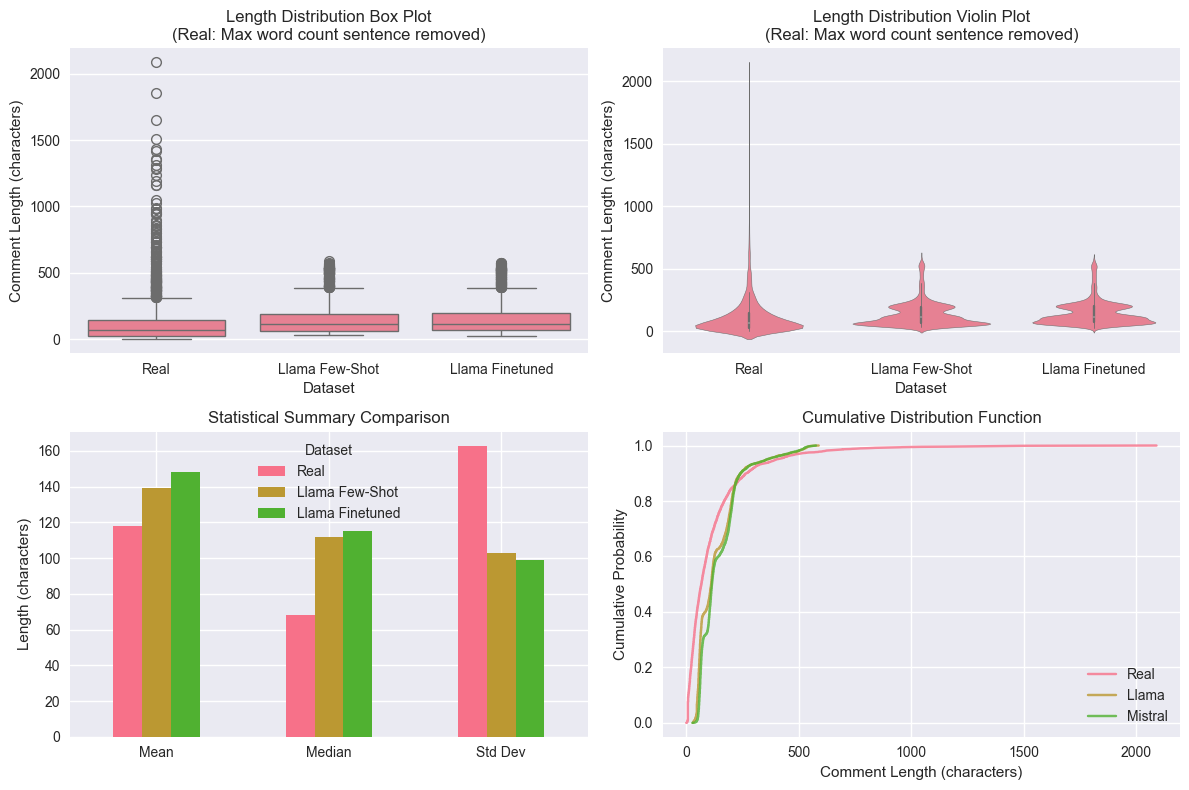

In [9]:
# Box plots for statistical comparison
plt.figure(figsize=(12, 8))

# Create a dataframe for box plotting (real data already has max word count sentence removed)
import pandas as pd

length_data = pd.DataFrame({
    'Length': list(real_length) + list(llama_few_shot_length) + list(llama_finetuned_length),
    'Dataset': ['Real'] * len(real_length) + ['Llama Few-Shot'] * len(llama_few_shot_length) + ['Llama Finetuned'] * len(llama_finetuned_length)
})

# Box plot
plt.subplot(2, 2, 1)
sns.boxplot(data=length_data, x='Dataset', y='Length')
plt.title('Length Distribution Box Plot\n(Real: Max word count sentence removed)')
plt.ylabel('Comment Length (characters)')

# Violin plot
plt.subplot(2, 2, 2)
sns.violinplot(data=length_data, x='Dataset', y='Length')
plt.title('Length Distribution Violin Plot\n(Real: Max word count sentence removed)')
plt.ylabel('Comment Length (characters)')

# Summary statistics comparison
plt.subplot(2, 2, 3)
summary_stats = pd.DataFrame({
    'Real': [real_length.mean(), real_length.median(), real_length.std()],
    'Llama Few-Shot': [llama_few_shot_length.mean(), llama_few_shot_length.median(), llama_few_shot_length.std()],
    'Llama Finetuned': [llama_finetuned_length.mean(), llama_finetuned_length.median(), llama_finetuned_length.std()]
}, index=['Mean', 'Median', 'Std Dev'])

summary_stats.plot(kind='bar', ax=plt.gca())
plt.title('Statistical Summary Comparison')
plt.ylabel('Length (characters)')
plt.xticks(rotation=0)
plt.legend(title='Dataset')

# CDF comparison
plt.subplot(2, 2, 4)
sorted_real = np.sort(real_length)
sorted_llama = np.sort(llama_few_shot_length)
sorted_mistral = np.sort(llama_finetuned_length)

p_real = np.arange(1, len(sorted_real) + 1) / len(sorted_real)
p_llama = np.arange(1, len(sorted_llama) + 1) / len(sorted_llama)
p_mistral = np.arange(1, len(sorted_mistral) + 1) / len(sorted_mistral)

plt.plot(sorted_real, p_real, label='Real', alpha=0.8)
plt.plot(sorted_llama, p_llama, label='Llama', alpha=0.8)
plt.plot(sorted_mistral, p_mistral, label='Mistral', alpha=0.8)
plt.xlabel('Comment Length (characters)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
# Detailed statistics table (real data already has max word count sentence removed)
print("\nDetailed Length Statistics:")
print("=" * 60)

stats_df = pd.DataFrame({
    'Real Comments': real_length.describe(),
    'Llama Few-Shot Generated': llama_few_shot_length.describe(),
    'Llama Finetuned Generated': llama_finetuned_length.describe()
})

print(stats_df.round(2))

# Additional percentile analysis
print("\nAdditional Percentiles:")
print("=" * 60)

percentiles = [5, 10, 25, 75, 90, 95, 99]
percentile_df = pd.DataFrame({
    'Real Comments': [np.percentile(real_length, p) for p in percentiles],
    'Llama Few-Shot Generated': [np.percentile(llama_few_shot_length, p) for p in percentiles],
    'Llama Finetuned Generated': [np.percentile(llama_finetuned_length, p) for p in percentiles]
}, index=[f'{p}th percentile' for p in percentiles])

print(percentile_df.round(2))


Detailed Length Statistics:
       Real Comments  Llama Few-Shot Generated  Llama Finetuned Generated
count        3196.00                   3197.00                    3197.00
mean          118.20                    139.32                     148.24
std           162.69                    102.92                      98.96
min             1.00                     30.00                      28.00
25%            28.00                     61.00                      69.00
50%            68.00                    112.00                     115.00
75%           143.00                    192.00                     198.00
max          2089.00                    589.00                     577.00

Additional Percentiles:
                 Real Comments  Llama Few-Shot Generated  \
5th percentile            8.00                     48.00   
10th percentile          10.00                     51.00   
25th percentile          28.00                     61.00   
75th percentile         143.00          

In [11]:
## Calculate word counts for all datasets (real data already has max word count sentence removed)

# Calculate word counts
real_word_count = real["text"].str.split().str.len()
llama_few_shot_word_count = llama_few_shot["generated_comment"].str.split().str.len()
llama_finetuned_word_count = llama_finetuned["generated_comment"].str.split().str.len()

print("Word Count Statistics (after removing max word count sentence):")
print("=" * 60)
print(f"Real comments - Count: {len(real_word_count)}, Mean words: {real_word_count.mean():.2f}, Median: {real_word_count.median():.2f}, Min: {real_word_count.min()}, Max: {real_word_count.max()}")
print(f"Llama Few-Shot generated - Count: {len(llama_few_shot_word_count)}, Mean words: {llama_few_shot_word_count.mean():.2f}, Median: {llama_few_shot_word_count.median():.2f}, Min: {llama_few_shot_word_count.min()}, Max: {llama_few_shot_word_count.max()}")
print(f"Llama Finetuned generated - Count: {len(llama_finetuned_word_count)}, Mean words: {llama_finetuned_word_count.mean():.2f}, Median: {llama_finetuned_word_count.median():.2f}, Min: {llama_finetuned_word_count.min()}, Max: {llama_finetuned_word_count.max()}")

Word Count Statistics (after removing max word count sentence):
Real comments - Count: 3196, Mean words: 20.51, Median: 12.00, Min: 1, Max: 336
Llama Few-Shot generated - Count: 3197, Mean words: 24.62, Median: 19.00, Min: 2, Max: 120
Llama Finetuned generated - Count: 3197, Mean words: 26.11, Median: 21.00, Min: 2, Max: 109


In [12]:
import pandas as pd
import numpy as np
import pickle

# Load your training data

# Calculate word counts for all real comments
word_counts = real['text'].apply(lambda x: len(str(x).split())).values

# Save distribution
distribution = {
    'word_counts': word_counts,
    'mean': np.mean(word_counts),
    'median': np.median(word_counts),
    'percentiles': {
        'p25': np.percentile(word_counts, 25),
        'p50': np.percentile(word_counts, 50),
        'p75': np.percentile(word_counts, 75),
        'p90': np.percentile(word_counts, 90),
    }
}

# Save to file
with open('real_length_distribution.pkl', 'wb') as f:
    pickle.dump(distribution, f)

print(f"Saved distribution:")
print(f"  Mean: {distribution['mean']:.2f}")
print(f"  Median: {distribution['median']:.2f}")
print(f"  25th percentile: {distribution['percentiles']['p25']:.2f}")
print(f"  75th percentile: {distribution['percentiles']['p75']:.2f}")
print(f"  90th percentile: {distribution['percentiles']['p90']:.2f}")

Saved distribution:
  Mean: 20.51
  Median: 12.00
  25th percentile: 5.00
  75th percentile: 25.00
  90th percentile: 47.00


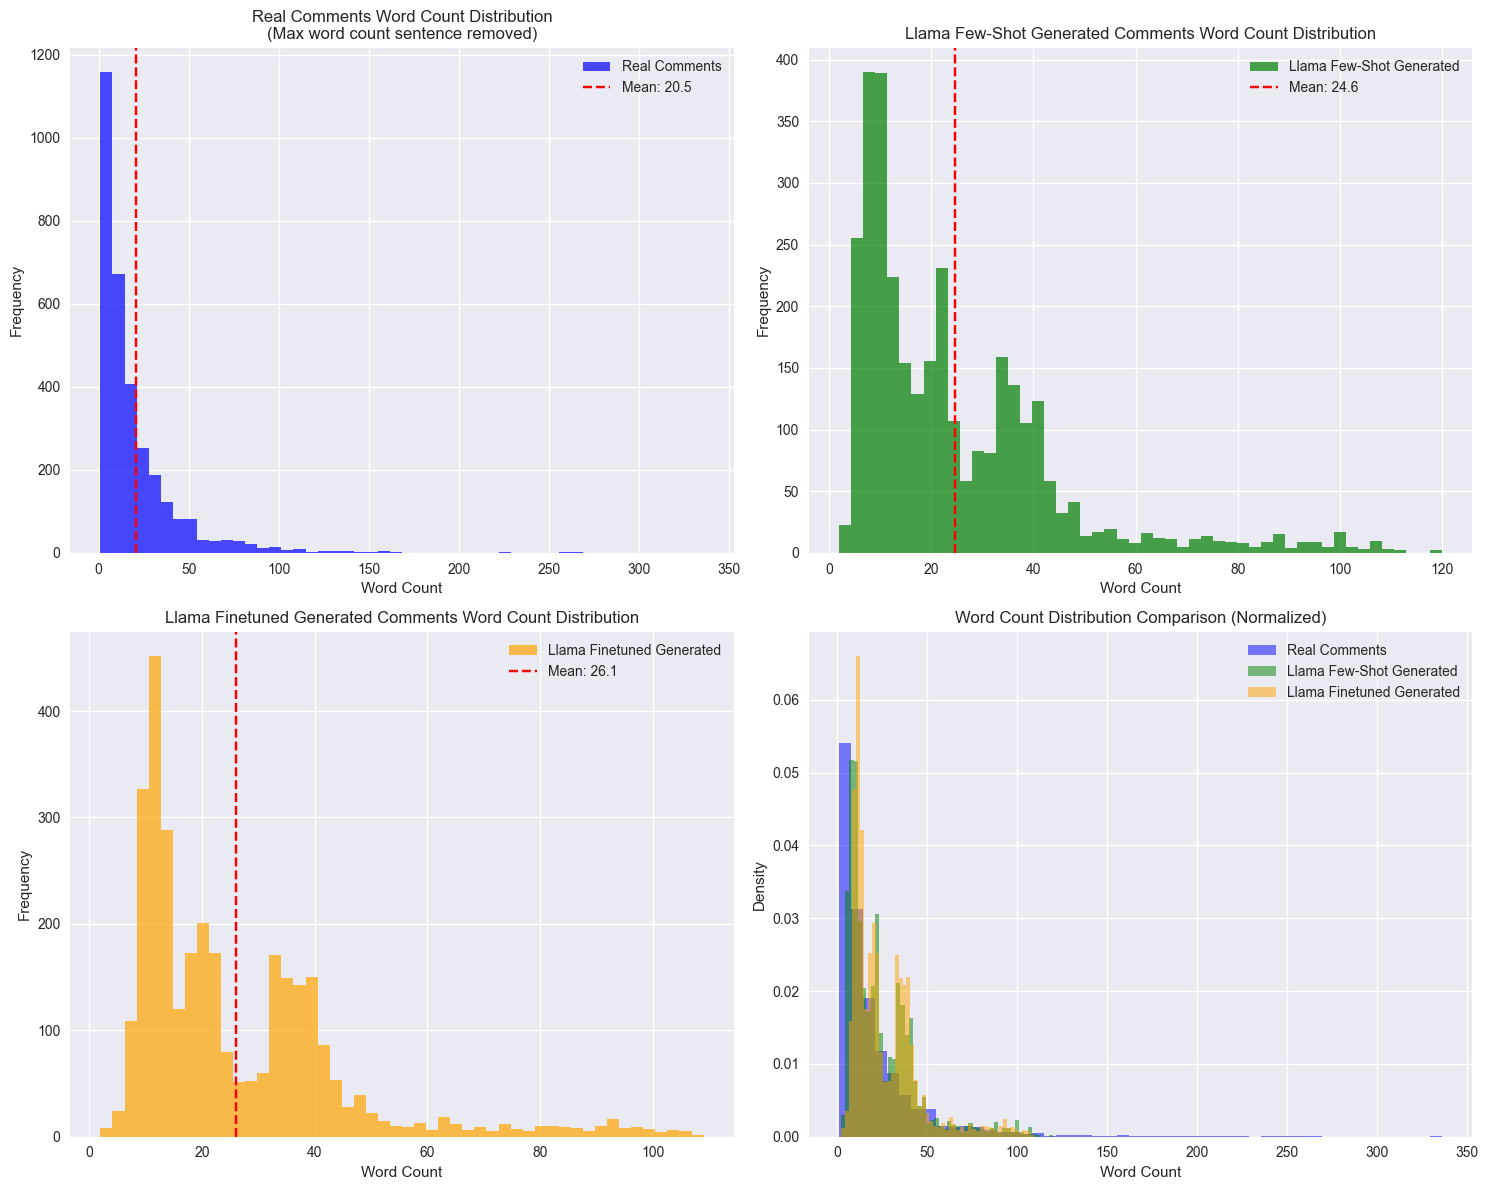

In [13]:
# Word Count Distribution Plots (real data already has max word count sentence removed)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Individual histograms for word counts
axes[0,0].hist(real_word_count, bins=50, alpha=0.7, label='Real Comments', color='blue')
axes[0,0].set_title('Real Comments Word Count Distribution\n(Max word count sentence removed)')
axes[0,0].set_xlabel('Word Count')
axes[0,0].set_ylabel('Frequency')
axes[0,0].axvline(real_word_count.mean(), color='red', linestyle='--', label=f'Mean: {real_word_count.mean():.1f}')
axes[0,0].legend()

axes[0,1].hist(llama_few_shot_word_count, bins=50, alpha=0.7, label='Llama Few-Shot Generated', color='green')
axes[0,1].set_title('Llama Few-Shot Generated Comments Word Count Distribution')
axes[0,1].set_xlabel('Word Count')
axes[0,1].set_ylabel('Frequency')
axes[0,1].axvline(llama_few_shot_word_count.mean(), color='red', linestyle='--', label=f'Mean: {llama_few_shot_word_count.mean():.1f}')
axes[0,1].legend()

axes[1,0].hist(llama_finetuned_word_count, bins=50, alpha=0.7, label='Llama Finetuned Generated', color='orange')
axes[1,0].set_title('Llama Finetuned Generated Comments Word Count Distribution')
axes[1,0].set_xlabel('Word Count')
axes[1,0].set_ylabel('Frequency')
axes[1,0].axvline(llama_finetuned_word_count.mean(), color='red', linestyle='--', label=f'Mean: {llama_finetuned_word_count.mean():.1f}')
axes[1,0].legend()

# 2. Overlapping histograms for word count comparison
axes[1,1].hist(real_word_count, bins=50, alpha=0.5, label='Real Comments', color='blue', density=True)
axes[1,1].hist(llama_few_shot_word_count, bins=50, alpha=0.5, label='Llama Few-Shot Generated', color='green', density=True)
axes[1,1].hist(llama_finetuned_word_count, bins=50, alpha=0.5, label='Llama Finetuned Generated', color='orange', density=True)
axes[1,1].set_title('Word Count Distribution Comparison (Normalized)')
axes[1,1].set_xlabel('Word Count')
axes[1,1].set_ylabel('Density')
axes[1,1].legend()

plt.tight_layout()
plt.show()

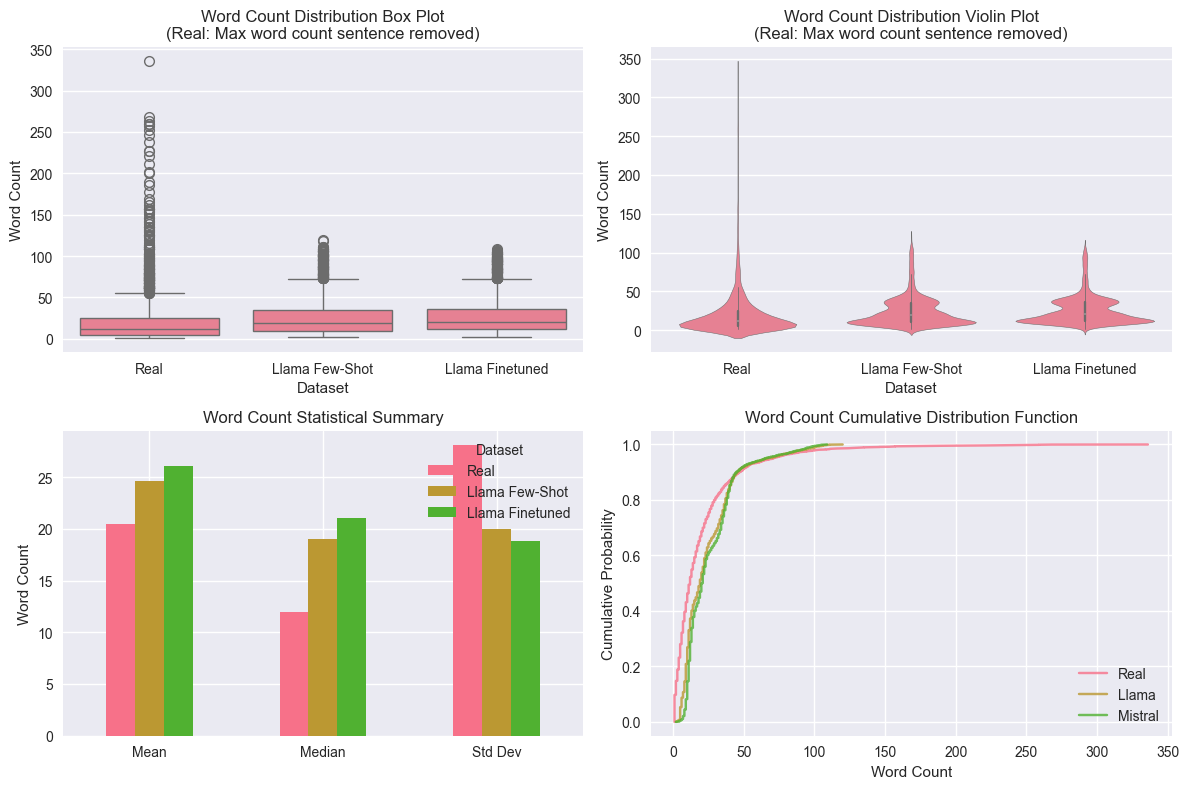

In [14]:
# Word Count Box plots and statistical comparison (real data already has max word count sentence removed)
plt.figure(figsize=(12, 8))

# Create a dataframe for word count box plotting
word_count_data = pd.DataFrame({
    'Word_Count': list(real_word_count) + list(llama_few_shot_word_count) + list(llama_finetuned_word_count),
    'Dataset': ['Real'] * len(real_word_count) + ['Llama Few-Shot'] * len(llama_few_shot_word_count) + ['Llama Finetuned'] * len(llama_finetuned_word_count)
})

# Box plot for word counts
plt.subplot(2, 2, 1)
sns.boxplot(data=word_count_data, x='Dataset', y='Word_Count')
plt.title('Word Count Distribution Box Plot\n(Real: Max word count sentence removed)')
plt.ylabel('Word Count')

# Violin plot for word counts
plt.subplot(2, 2, 2)
sns.violinplot(data=word_count_data, x='Dataset', y='Word_Count')
plt.title('Word Count Distribution Violin Plot\n(Real: Max word count sentence removed)')
plt.ylabel('Word Count')

# Summary statistics comparison for word counts
plt.subplot(2, 2, 3)
word_summary_stats = pd.DataFrame({
    'Real': [real_word_count.mean(), real_word_count.median(), real_word_count.std()],
    'Llama Few-Shot': [llama_few_shot_word_count.mean(), llama_few_shot_word_count.median(), llama_few_shot_word_count.std()],
    'Llama Finetuned': [llama_finetuned_word_count.mean(), llama_finetuned_word_count.median(), llama_finetuned_word_count.std()]
}, index=['Mean', 'Median', 'Std Dev'])

word_summary_stats.plot(kind='bar', ax=plt.gca())
plt.title('Word Count Statistical Summary')
plt.ylabel('Word Count')
plt.xticks(rotation=0)
plt.legend(title='Dataset')

# CDF comparison for word counts
plt.subplot(2, 2, 4)
sorted_real_words = np.sort(real_word_count)
sorted_llama_words = np.sort(llama_few_shot_word_count)
sorted_mistral_words = np.sort(llama_finetuned_word_count)

p_real_words = np.arange(1, len(sorted_real_words) + 1) / len(sorted_real_words)
p_llama_words = np.arange(1, len(sorted_llama_words) + 1) / len(sorted_llama_words)
p_mistral_words = np.arange(1, len(sorted_mistral_words) + 1) / len(sorted_mistral_words)

plt.plot(sorted_real_words, p_real_words, label='Real', alpha=0.8)
plt.plot(sorted_llama_words, p_llama_words, label='Llama', alpha=0.8)
plt.plot(sorted_mistral_words, p_mistral_words, label='Mistral', alpha=0.8)
plt.xlabel('Word Count')
plt.ylabel('Cumulative Probability')
plt.title('Word Count Cumulative Distribution Function')
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
# Detailed Word Count Statistics (real data already has max word count sentence removed)
print("\nDetailed Word Count Statistics:")
print("=" * 60)

word_stats_df = pd.DataFrame({
    'Real Comments': real_word_count.describe(),
    'Llama Few-Shot Generated': llama_few_shot_word_count.describe(),
    'Llama Finetuned Generated': llama_finetuned_word_count.describe()
})

print(word_stats_df.round(2))

# Word count percentile analysis
print("\nWord Count Percentiles:")
print("=" * 60)

word_percentile_df = pd.DataFrame({
    'Real Comments': [np.percentile(real_word_count, p) for p in percentiles],
    'Llama Few-Shot Generated': [np.percentile(llama_few_shot_word_count, p) for p in percentiles],
    'Llama Finetuned Generated': [np.percentile(llama_finetuned_word_count, p) for p in percentiles]
}, index=[f'{p}th percentile' for p in percentiles])

print(word_percentile_df.round(2))


Detailed Word Count Statistics:
       Real Comments  Llama Few-Shot Generated  Llama Finetuned Generated
count        3196.00                   3197.00                    3197.00
mean           20.51                     24.62                      26.11
std            28.09                     19.97                      18.84
min             1.00                      2.00                       2.00
25%             5.00                     10.00                      12.00
50%            12.00                     19.00                      21.00
75%            25.00                     35.00                      36.00
max           336.00                    120.00                     109.00

Word Count Percentiles:
                 Real Comments  Llama Few-Shot Generated  \
5th percentile             1.0                       5.0   
10th percentile            2.0                       7.0   
25th percentile            5.0                      10.0   
75th percentile           25.0      

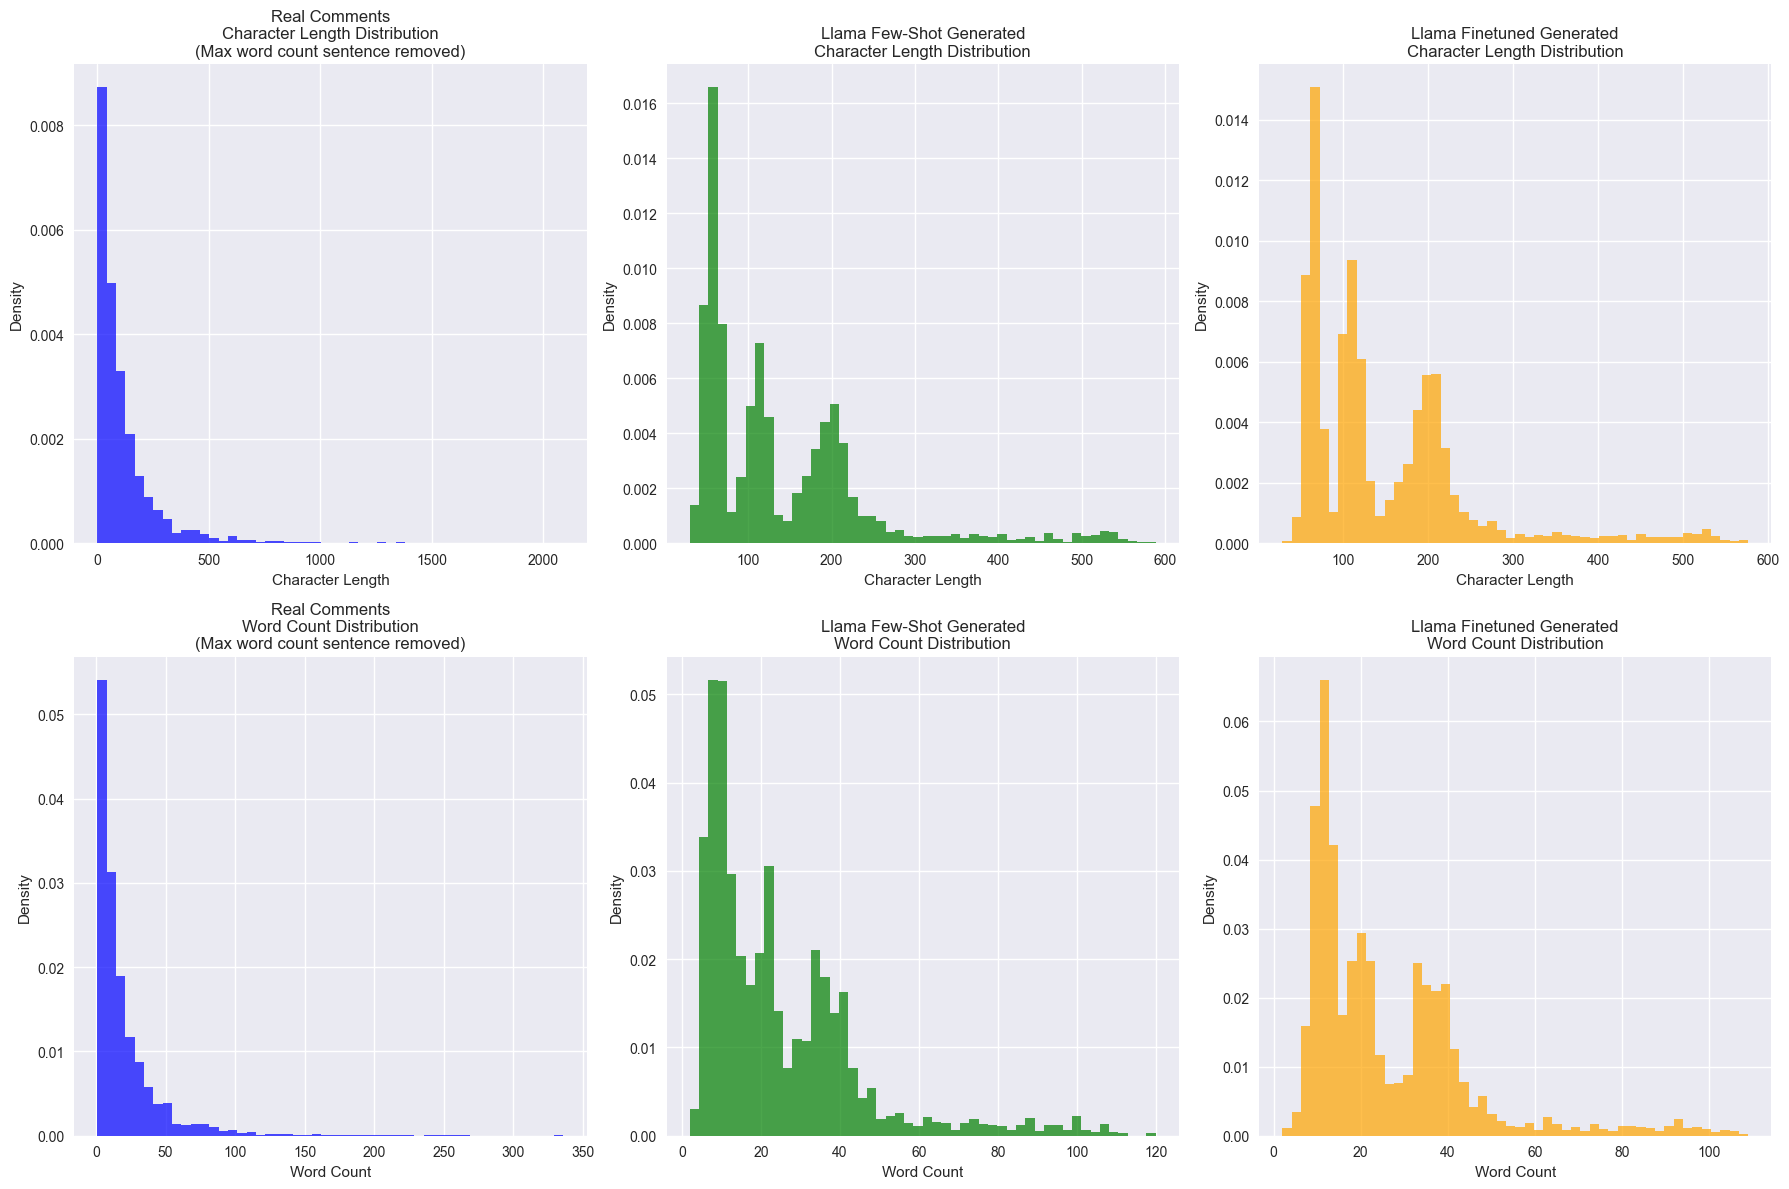

In [16]:
# Combined Character Length vs Word Count Comparison (real data already has max word count sentence removed)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Character length distributions
axes[0,0].hist(real_length, bins=50, alpha=0.7, color='blue', density=True)
axes[0,0].set_title('Real Comments\nCharacter Length Distribution\n(Max word count sentence removed)')
axes[0,0].set_xlabel('Character Length')
axes[0,0].set_ylabel('Density')

axes[0,1].hist(llama_few_shot_length, bins=50, alpha=0.7, color='green', density=True)
axes[0,1].set_title('Llama Few-Shot Generated\nCharacter Length Distribution')
axes[0,1].set_xlabel('Character Length')
axes[0,1].set_ylabel('Density')

axes[0,2].hist(llama_finetuned_length, bins=50, alpha=0.7, color='orange', density=True)
axes[0,2].set_title('Llama Finetuned Generated\nCharacter Length Distribution')
axes[0,2].set_xlabel('Character Length')
axes[0,2].set_ylabel('Density')

# Word count distributions
axes[1,0].hist(real_word_count, bins=50, alpha=0.7, color='blue', density=True)
axes[1,0].set_title('Real Comments\nWord Count Distribution\n(Max word count sentence removed)')
axes[1,0].set_xlabel('Word Count')
axes[1,0].set_ylabel('Density')

axes[1,1].hist(llama_few_shot_word_count, bins=50, alpha=0.7, color='green', density=True)
axes[1,1].set_title('Llama Few-Shot Generated\nWord Count Distribution')
axes[1,1].set_xlabel('Word Count')
axes[1,1].set_ylabel('Density')

axes[1,2].hist(llama_finetuned_word_count, bins=50, alpha=0.7, color='orange', density=True)
axes[1,2].set_title('Llama Finetuned Generated\nWord Count Distribution')
axes[1,2].set_xlabel('Word Count')
axes[1,2].set_ylabel('Density')

plt.tight_layout()
plt.show()